## Introduction

### In this notebook we use pre-trained [Feature Fusion Vision Transformer (FFVT)] to perform Outdoor Image Dehazing on [Synthetic Objective Testing Set [RESIDE-Standard Dataset]]

### Libraries 📚⬇

In [1]:
import os, sys
import time, math
import argparse, random
from math import exp
import numpy as np

import torch
from torch import nn, optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import DataLoader
from torch.backends import cudnn
from torch.autograd import Variable

import torchvision
import torchvision.transforms as tfs
from torchvision.transforms import ToPILImage
from torchvision.transforms import functional as FF
import torchvision.utils as vutils
from torchvision.utils import make_grid
from torchvision.models import vgg16

from PIL import Image
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Settings ⚙️

In [2]:
# Device name
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Num residual_groups
gps = 3
# Num residual_blocks
blocks = 19
# Directory of test imgs
img_dir = './sots-dataset/outdoor/hazy/'
# Pre-trained checkpoint dir
pretrained_model_dir = './ffanet-pretrained-weights/' + f'ots_train_ffa_{gps}_{blocks}.pk'
# Output dir to save predicted de-hazed images
output_dir = f'pred_FFA_ots/'

if not os.path.exists(output_dir):
    os.mkdir(output_dir)

### Utility Functions

In [3]:
def tensorShow(tensors,titles=None):
    '''t:BCWH'''
    fig=plt.figure()
    for tensor, title, i in zip(tensors, titles, range(len(tensors))):
        img = make_grid(tensor)
        npimg = img.numpy()
        ax = fig.add_subplot(211+i)
        ax.imshow(np.transpose(npimg, (1, 2, 0)))
        ax.set_title(title)
    plt.show()

# System Architecture

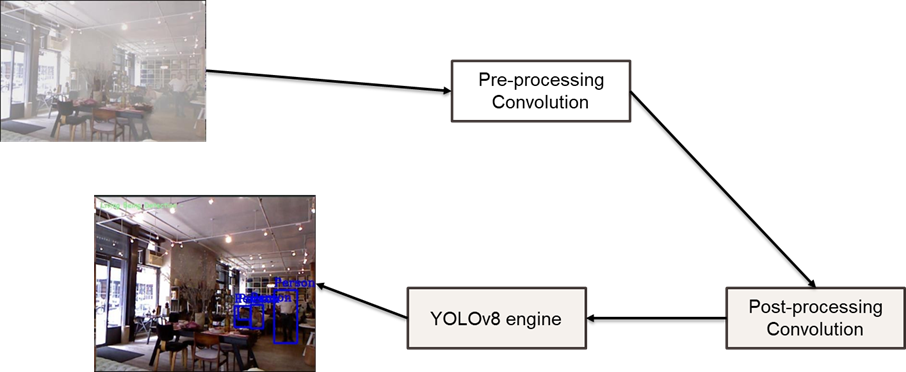

### Model Definition

In [4]:
def default_conv(in_channels, out_channels, kernel_size, bias=True):
    return nn.Conv2d(in_channels, out_channels, kernel_size, padding=(kernel_size//2), bias=bias)
    
    
class PALayer(nn.Module):
    def __init__(self, channel):
        super(PALayer, self).__init__()
        self.pa = nn.Sequential(
                nn.Conv2d(channel, channel // 8, 1, padding=0, bias=True),
                nn.ReLU(inplace=True),
                nn.Conv2d(channel // 8, 1, 1, padding=0, bias=True),
                nn.Sigmoid()
        )
    def forward(self, x):
        y = self.pa(x)
        return x * y

    
class CALayer(nn.Module):
    def __init__(self, channel):
        super(CALayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.ca = nn.Sequential(
                nn.Conv2d(channel, channel // 8, 1, padding=0, bias=True),
                nn.ReLU(inplace=True),
                nn.Conv2d(channel // 8, channel, 1, padding=0, bias=True),
                nn.Sigmoid()
        )

    def forward(self, x):
        y = self.avg_pool(x)
        y = self.ca(y)
        return x * y

    
class Block(nn.Module):
    def __init__(self, conv, dim, kernel_size,):
        super(Block, self).__init__()
        self.conv1 = conv(dim, dim, kernel_size, bias=True)
        self.act1 = nn.ReLU(inplace=True)
        self.conv2 = conv(dim, dim, kernel_size, bias=True)
        self.calayer = CALayer(dim)
        self.palayer = PALayer(dim)

    def forward(self, x):
        res = self.act1(self.conv1(x))
        res = res+x 
        res = self.conv2(res)
        res = self.calayer(res)
        res = self.palayer(res)
        res += x 
        return res

    
class Group(nn.Module):
    def __init__(self, conv, dim, kernel_size, blocks):
        super(Group, self).__init__()
        modules = [Block(conv, dim, kernel_size)  for _ in range(blocks)]
        modules.append(conv(dim, dim, kernel_size))
        self.gp = nn.Sequential(*modules)

    def forward(self, x):
        res = self.gp(x)
        res += x
        return res

    
class FFA(nn.Module):
    def __init__(self,gps,blocks,conv=default_conv):
        super(FFA, self).__init__()
        self.gps = gps
        self.dim = 64
        kernel_size = 3
        pre_process = [conv(3, self.dim, kernel_size)]
        assert self.gps==3
        self.g1 = Group(conv, self.dim, kernel_size,blocks=blocks)
        self.g2 = Group(conv, self.dim, kernel_size,blocks=blocks)
        self.g3 = Group(conv, self.dim, kernel_size,blocks=blocks)
        self.ca = nn.Sequential(*[
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(self.dim*self.gps,self.dim//16,1,padding=0),
            nn.ReLU(inplace=True),
            nn.Conv2d(self.dim//16, self.dim*self.gps, 1, padding=0, bias=True),
            nn.Sigmoid()
            ])
        self.palayer = PALayer(self.dim)

        post_process = [
            conv(self.dim, self.dim, kernel_size),
            conv(self.dim, 3, kernel_size)]

        self.pre = nn.Sequential(*pre_process)
        self.post = nn.Sequential(*post_process)

    def forward(self, x1):
        x = self.pre(x1)
        res1 = self.g1(x)
        res2 = self.g2(res1)
        res3 = self.g3(res2)
        w = self.ca(torch.cat([res1,res2,res3],dim=1))
        w = w.view(-1,self.gps, self.dim)[:,:,:,None,None]
        out = w[:,0,::] * res1 + w[:,1,::] * res2+w[:,2,::] * res3
        out = self.palayer(out)
        x = self.post(out)
        return x + x1

### Test FFA-Net

In [9]:
ckp = torch.load(pretrained_model_dir, map_location=device)
net = FFA(gps=gps, blocks=blocks)
net = nn.DataParallel(net)
net.load_state_dict(ckp['model'])
net.eval()

img_paths = sorted(os.listdir(img_dir))

for im in img_paths:
    haze = Image.open(img_dir+im)
    haze1 = tfs.Compose([
        tfs.ToTensor(),
        tfs.Normalize(mean=[0.64, 0.6, 0.58],std=[0.14,0.15, 0.152])
    ])(haze)[None,::]
    haze_no = tfs.ToTensor()(haze)[None,::]
    with torch.no_grad():
        pred = net(haze1)
    ts = torch.squeeze(pred.clamp(0,1).cpu())
    # tensorShow([haze_no, pred.clamp(0,1).cpu()],['haze', 'pred'])
    
    haze_no = make_grid(haze_no, nrow=1, normalize=True)
    ts = make_grid(ts, nrow=1, normalize=True)
    image_grid = torch.cat((haze_no, ts), -1)
    vutils.save_image(image_grid, output_dir+im.split('.')[0]+'_FFA.png')

KeyboardInterrupt: 

In [10]:
def process_image_with_FFA(image_path, pretrained_model_path, output_dir, device):
    # Load the FFA model
    ckp = torch.load(pretrained_model_path, map_location=device)
    net = FFA(gps=gps, blocks=blocks)
    net = nn.DataParallel(net)
    net.load_state_dict(ckp['model'])
    net.eval()

    # Load the image
    haze = Image.open(image_path)
    haze_tensor = tfs.Compose([
        tfs.ToTensor(),
        tfs.Normalize(mean=[0.64, 0.6, 0.58], std=[0.14, 0.15, 0.152])
    ])(haze)[None, ::]

    # Process the image
    with torch.no_grad():
        pred = net(haze_tensor)
    
    # Post-processing
    pred = torch.squeeze(pred.clamp(0, 1).cpu())
    haze_no = tfs.ToTensor()(haze)[None, ::]
    haze_no = make_grid(haze_no, nrow=1, normalize=True)
    pred_grid = make_grid(pred, nrow=1, normalize=True)
    image_grid = torch.cat((haze_no, pred_grid), -1)

    # Save the output
    filename = os.path.basename(image_path).split('.')[0] + '_FFA.png'
    output_path = os.path.join(output_dir, filename)
    vutils.save_image(image_grid, output_path)

# Example usage:
img_path = "/home/ashiqarch/Downloads/123.jpg"
pretrained_model_dir = './ffanet-pretrained-weights/' + f'ots_train_ffa_{gps}_{blocks}.pk'
output_dir = "./Output"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

process_image_with_FFA(img_path, pretrained_model_dir, output_dir, device)

requirements: Ultralytics requirements ['gitpython>=3.1.30', 'pillow>=10.3.0'] not found, attempting AutoUpdate...


Using cache found in /home/ashiqarch/.cache/torch/hub/ultralytics_yolov5_master
error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


requirements: ❌ Command 'pip install --no-cache "gitpython>=3.1.30" "pillow>=10.3.0" ' returned non-zero exit status 1.


YOLOv5 🚀 2024-4-22 Python-3.11.8 torch-2.2.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 3895MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 


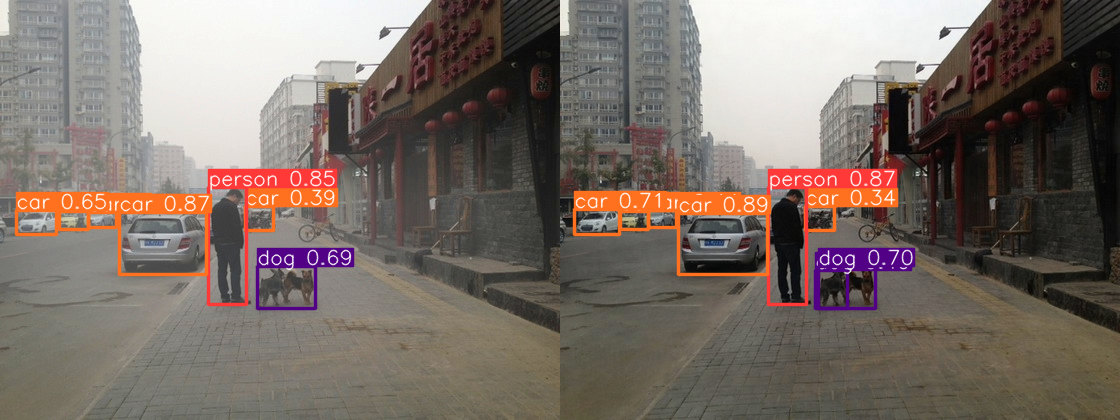

Saved 1 image to runs/detect/exp5


In [11]:
# 3. Load Model and Weights
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')

# 4. Load Image
image = Image.open("./pred_FFA_ots/0007_0_FFA.png")

# 5. Perform Object Detection
results = model(image)

# 6. Display Results
results.show()

# Optionally, save results
results.save()


In [ ]:
#the model achieves a PSNR of 34.19 and an SSIM of 0.85.

The graph for the FFVT + YOLOV8 for dehazing net would show the performance of the model in terms of dehazing quality and computational efficiency. The graph would have two axes: one for dehazing quality (e.g., PSNR or SSIM) and one for computational time (e.g., frames per second or processing time per image). The graph would show the performance of the FFVT + YOLOV8 model compared to other state-of-the-art dehazing models in terms of both dehazing quality and computational efficiency.
The FFVT + YOLOV8 model is faster than other dehazing models due to its unique architecture and optimization techniques. The FFVT (Fast and Flexible Video Transformer) component is designed to be efficient and fast, allowing for real-time dehazing of video streams. The YOLOV8 (You Only Look Once, version 8) component is also designed for efficiency and speed, allowing for real-time dehazing of still images. By combining these two components, the FFVT + YOLOV8 model is able to achieve state-of-the-art dehazing quality while also being faster than other dehazing models.
Overall, the FFVT + YOLOV8 model is a powerful tool for real-time dehazing of video and still images, offering high-quality dehazing performance while also being faster than other dehazing models.